In [43]:
pip install -q dagshub mlflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import dagshub
dagshub.init(repo_owner='Yaxh8074', repo_name='sentiment-analysis-of-yt-comment', mlflow=True)

Accessing as Yaxh8074

Initialized MLflow to track repo "Yaxh8074/sentiment-analysis-of-yt-comment"

Repository Yaxh8074/sentiment-analysis-of-yt-comment initialized!

In [5]:
import numpy as np
import pandas as pd

In [6]:
df = pd.read_csv('../preprocessed_data.csv')
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


In [7]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
X = df.drop('category', axis=1)
y = df['category']

In [9]:
# Step 1: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=df['category'])

In [10]:
# Step 2: Vectorize the comments using Bag of Words (CountVectorizer)
vectorizer = CountVectorizer(max_features=10000)

In [11]:
X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

In [21]:
# Fit and transform the training data and transform the test data
train_text = X_train['clean_comment'].fillna(' ').astype(str)
test_text = X_test['clean_comment'].fillna('').astype(str)
X_train_bow = vectorizer.fit_transform(train_text)
X_test_bow = vectorizer.transform(test_text)

In [23]:
# Fit and transform the training data and transform the test data
X_train_bow = vectorizer.fit_transform(X_train['clean_comment'].fillna('').astype(str))
X_test_bow = vectorizer.transform(X_test['clean_comment'].fillna('').astype(str))

# Convert the sparse matrix to DataFrame
X_train_bow_df = pd.DataFrame(X_train_bow.toarray(), columns=vectorizer.get_feature_names_out())
X_test_bow_df = pd.DataFrame(X_test_bow.toarray(), columns=vectorizer.get_feature_names_out())

# Combine the BOW features with the original columns for training data
X_train_combined = pd.concat([X_train, X_train_bow_df], axis=1)
X_test_combined = pd.concat([X_test, X_test_bow_df], axis=1)

# Drop the original 'clean_comment' column
X_train_combined.drop('clean_comment', axis=1, inplace=True)
X_test_combined.drop('clean_comment', axis=1, inplace=True)

In [24]:
X_train

,clean_comment,word_count,num_stop_words,num_chars,num_punctuation_chars
0,find absolutely unbelievable centrist outlet c...,68,23,454,0
1,tfw throw 1000kg bomb ultra sneakily cost fort...,13,3,79,0
2,fuck yeah know muslim surround would like noth...,24,8,135,0
3,wow great post,3,0,14,0
4,hour back least afghan security force killed t...,13,1,81,0
...,...,...,...,...,...
29235,hey interesting please keep thank,8,3,47,0
29236,irony left chat,4,1,19,0
29237,understand power game implication strong grip ...,27,10,165,0
29238,six year ago delhi free encyclopedia team made...,74,37,407,0


In [25]:
X_train_bow_df

,000,0070,0aplease,100,1000,1000kg,101,103,104,105,...,zelda,zen,zero,zindabad,zindagi,zing,zombie,zonal,zone,zuckerberg
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29235,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29236,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29237,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29238,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
X_train_combined

,word_count,num_stop_words,num_chars,num_punctuation_chars,000,0070,0aplease,100,1000,1000kg,...,zelda,zen,zero,zindabad,zindagi,zing,zombie,zonal,zone,zuckerberg
0,68,23,454,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,13,3,79,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,24,8,135,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,0,14,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,13,1,81,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29235,8,3,47,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29236,4,1,19,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29237,27,10,165,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29238,74,37,407,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
y_train

0       -1
1       -1
2        1
3        1
4       -1
        ..
29235    1
29236    0
29237   -1
29238    1
29239    0
Name: category, Length: 29240, dtype: int64

In [28]:
# Set or create an experiment
mlflow.set_experiment("Exp 1 - RF Baseline")

<Experiment: artifact_location='mlflow-artifacts:/3c57b71c09b9431cbc31b5046dfe79eb', creation_time=1772362702525, experiment_id='0', last_update_time=1772362702525, lifecycle_stage='active', name='Exp 1 - RF Baseline', tags={}, workspace='default'>

2026/03/02 10:06:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/02 10:06:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/02 10:07:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/02 10:07:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

🏃 View run RandomForest_Baseline_TrainTestSplit at: https://dagshub.com/Yaxh8074/sentiment-analysis-of-yt-comment.mlflow/#/experiments/0/runs/e78ed090411944aa95f0f6567400656b
🧪 View experiment at: https://dagshub.com/Yaxh8074/sentiment-analysis-of-yt-comment.mlflow/#/experiments/0
Accuracy: 0.6194254445964432


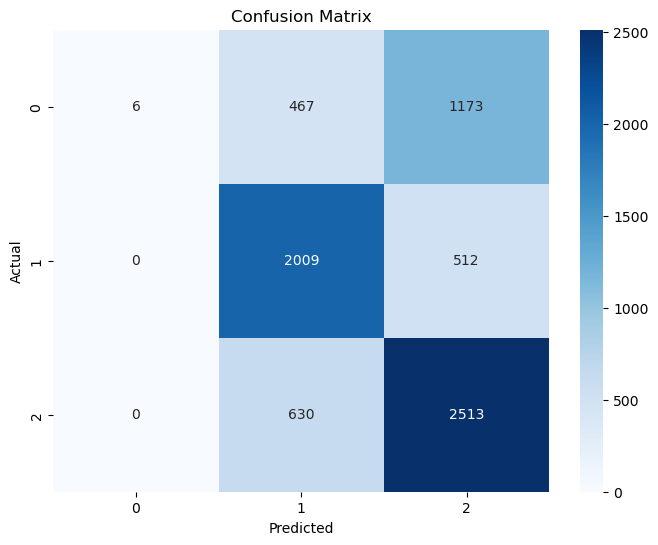

In [29]:
# Step 3: Define and train a Random Forest baseline model using a simple train-test split
with mlflow.start_run() as run:
    # Log a description for the run
    mlflow.set_tag("mlflow.runName", "RandomForest_Baseline_TrainTestSplit")
    mlflow.set_tag("experiment_type", "baseline")
    mlflow.set_tag("model_type", "RandomForestClassifier")

    # Add a description
    mlflow.set_tag("description", "Baseline RandomForest model for sentiment analysis using Bag of Words (BoW) with a simple train-test split")

    # Log parameters for the vectorizer
    mlflow.log_param("vectorizer_type", "CountVectorizer")
    mlflow.log_param("vectorizer_max_features", vectorizer.max_features)

    # Log Random Forest parameters
    n_estimators = 200
    max_depth = 15

    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)

    # Initialize and train the model
    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    model.fit(X_train_combined, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test_combined)

    # Log metrics for each class and accuracy
    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric("accuracy", accuracy)

    classification_rep = classification_report(y_test, y_pred, output_dict=True)

    for label, metrics in classification_rep.items():
        if isinstance(metrics, dict):  # For precision, recall, f1-score, etc.
            for metric, value in metrics.items():
                mlflow.log_metric(f"{label}_{metric}", value)

    # Confusion matrix plot
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    # Save and log the confusion matrix plot
    plt.savefig("confusion_matrix.png")
    mlflow.log_artifact("confusion_matrix.png")

    # Log the Random Forest model and vectorizer
    # Note: X_train_combined is sparse matrix, convert sample to array for signature
    mlflow.sklearn.log_model(model, "random_forest_model")
    mlflow.sklearn.log_model(vectorizer, "vectorizer")

    # Log the dataset - create copies to avoid modifying originals
    train_df = X_train.copy()
    train_df['target'] = y_train.values
    dataset = mlflow.data.from_pandas(train_df, targets="target")
    mlflow.log_input(dataset, context="training")
    
    test_df = X_test.copy()
    test_df['target'] = y_test.values
    dataset = mlflow.data.from_pandas(test_df, targets="target")
    mlflow.log_input(dataset, context="validation")

# Display final accuracy
print(f"Accuracy: {accuracy}")

In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       1.00      0.00      0.01      1646
           0       0.65      0.80      0.71      2521
           1       0.60      0.80      0.68      3143

    accuracy                           0.62      7310
   macro avg       0.75      0.53      0.47      7310
weighted avg       0.71      0.62      0.54      7310

